# Lab 2 &mdash; Fourier transform

## Submission rules:

1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file) downloaded from your team's Google Colab. Make sure you made a copy of the notebook above and opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **cms**.
2. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
3. This time, you also need to provide a **work breakdown structure** estimating the efforts of each team member. Please provide it at the top of your notebook.
4. This lab requires some visualization from you; please arrange it according to best practices (appropriate axes labels, title, size/scale are a minimum).
5. The final deadline is **March 17 2025, 23:59**. Making any changes to your code after this time and date is forbidden and will be a reason for point deduction for the whole team.

#### Work breakdown (example):

Name, surname 1: ....\
Name, surname 2: ....\
Mariia Hamaniuk 3:
Mykhailo Rykhalskyi: Sinusoids and Summary


## Introduction
Soon, you will learn about Fourier transform, i.e., an operator that maps functions depending on space (resp. time) variables into functions depending on spatial (resp. temporal) frequency, which is widely used in spectroscopy and signal processing.  

One of the motivations to use Fourier transform comes from the study of Fourier series. In our particular case, you will transform sound (a continuous wave that is a mixture of multiple frequencies) into an arrray of pure frequencies that can be analyzed with the help of Discrete Fourier Transform. The ultimate goal is to decompose a melody into a sequence of pitches and then to notes (without any help of a trained musician's ear &mdash; that would be cheating!).

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from IPython.display import Audio
%matplotlib inline

## Sinusoids

Let's first consider a simple example. Decompose a series sin3 that is a sum of two sinusoids using the Fast Fourier transform from scipy library. FFT is simply a computationally efficient implementation of a discrete Fourier transform. What is the frequency of sin1 and sin2 signals?

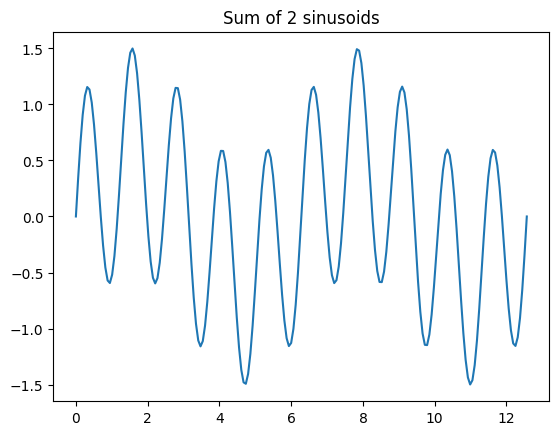

In [2]:
x = np.linspace(0, 4*np.pi, 200)
sin1 = 0.5 * np.sin(x)
sin2 = np.sin(5*x)
sin3 = sin1 + sin2
plt.plot(x, sin3)
plt.title('Sum of 2 sinusoids')
plt.show()


Apply FFT to sin3 series to obtain frequency decomposition and plot the results.

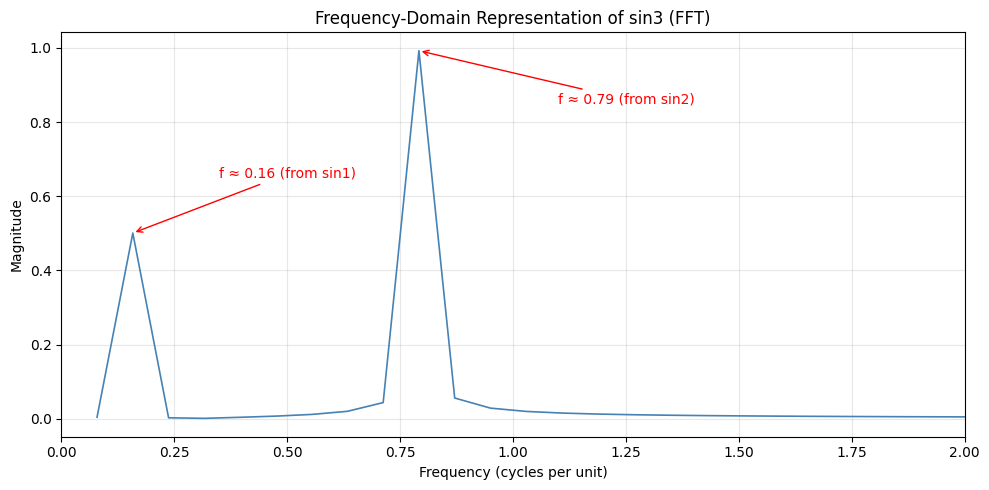

sin1 = 0.5·sin(x)  →  angular freq ω = 1  →  f = 1/(2π) ≈ 0.1592 cycles/unit
sin2 = sin(5x)     →  angular freq ω = 5  →  f = 5/(2π) ≈ 0.7958 cycles/unit


In [3]:
# Compute FFT of sin3
N = len(x)
dx = x[1] - x[0]  # sample spacing in the x-domain

yf = fft(sin3)
xf = fftfreq(N, dx)

# Keep only positive frequencies (spectrum is symmetric for real signals)
pos_mask = xf > 0
freqs = xf[pos_mask]
magnitudes = 2.0 / N * np.abs(yf[pos_mask])

# Plot frequency-domain representation
plt.figure(figsize=(10, 5))
plt.plot(freqs, magnitudes, color='steelblue', linewidth=1.2)
plt.title('Frequency-Domain Representation of sin3 (FFT)')
plt.xlabel('Frequency (cycles per unit)')
plt.ylabel('Magnitude')
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)

# Find the two actual peaks
from scipy.signal import find_peaks
peak_indices, _ = find_peaks(magnitudes, height=0.1)
# Sort by frequency so peak1 is the lower freq (sin1) and peak2 is higher (sin2)
peak_indices = sorted(peak_indices, key=lambda i: freqs[i])

# Annotate the two peaks
plt.annotate(f'f ≈ {freqs[peak_indices[0]]:.2f} (from sin1)',
             xy=(freqs[peak_indices[0]], magnitudes[peak_indices[0]]),
             xytext=(0.35, 0.65),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')
plt.annotate(f'f ≈ {freqs[peak_indices[1]]:.2f} (from sin2)',
             xy=(freqs[peak_indices[1]], magnitudes[peak_indices[1]]),
             xytext=(1.1, 0.85),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(f'sin1 = 0.5·sin(x)  →  angular freq ω = 1  →  f = 1/(2π) ≈ {1/(2*np.pi):.4f} cycles/unit')
print(f'sin2 = sin(5x)     →  angular freq ω = 5  →  f = 5/(2π) ≈ {5/(2*np.pi):.4f} cycles/unit')


Make sure that you got 2 spikes corresponding to the frequencies that we assigned to the sinusoids earlier. Explain how the transformation is conducted and why we can obtain two perfectly separated frequencies from a mixed signal.



---

**How the Discrete Fourier Transform decomposes sin3 into its constituent frequencies:**

The signal `sin3 = sin1 + sin2 = 0.5·sin(x) + sin(5x)` is a superposition of two pure sinusoids with angular frequencies ω₁ = 1 and ω₂ = 5 (equivalently, ordinary frequencies f₁ = 1/(2π) ≈ 0.16 and f₂ = 5/(2π) ≈ 0.80 cycles per unit).

The Discrete Fourier Transform (DFT), computed efficiently via the Fast Fourier Transform (FFT) algorithm, works by correlating the input signal with a family of complex exponentials (sinusoids) at evenly spaced frequencies. For each candidate frequency fₖ, the DFT computes:

$$X_k = \sum_{n=0}^{N-1} x_n \, e^{-2\pi i k n / N}$$

This inner product measures how much of the signal oscillates at frequency fₖ. When fₖ matches an actual component of the signal, the sum constructively accumulates and produces a large magnitude |Xₖ|. When fₖ does not match, the product oscillates and largely cancels out, yielding a near-zero magnitude.

Because `sin3` is composed of exactly two sinusoids, the magnitude spectrum |Xₖ| shows exactly two prominent spikes — one near f ≈ 0.16 (from `sin1`) and one near f ≈ 0.80 (from `sin2`). The height of each spike is proportional to the amplitude of the corresponding sinusoid: the spike from `sin2` (amplitude 1.0) is roughly twice as tall as the spike from `sin1` (amplitude 0.5).

The reason we can perfectly separate these two frequencies is that sinusoids of different frequencies are **orthogonal** — their inner product over a complete period is zero. The DFT exploits this orthogonality: each basis function $e^{-2\pi i k n / N}$ "picks out" only the component at its own frequency, effectively acting as a bank of narrow band-pass filters. This is why even though `sin3` looks like a complex, non-periodic wave in the time domain, the FFT cleanly resolves it into its two building blocks.

Small side-lobes visible around the main peaks are due to **spectral leakage**: since our signal is sampled over a finite interval that is not an exact integer multiple of both periods, truncation introduces minor artifacts. These can be reduced with windowing functions (e.g., Hann or Hamming windows), though for this simple example the leakage is minimal.

---

## Working with example audio

Now, let's work with a more complex wave&mdash;sound. Any sound (audio signal) can be characterized by the following three quantities: Pitch, Quality, and Loudness.

Loudness is a physiological sensation that depends mainly on the sound wave pressure (amplitude).

The lowest note in a chord is called fundamental. It is heard predominantly due to larger intensity. Quality is determined by overtones or harmonics that add to the sound of a fundamental note.

Pitch is the frequency of a sound as perceived by human ear. A high frequency gives rise to a high pitch note and a low frequency produces a low pitch note. A pure tone is the sound of only one frequency, such as that given by a tuning fork or electronic signal generator. Naturally, music does not consist of pure tones. Depending on an instrument, technique and many other factors, sound will decay at different rates and one tone will mix with the other ones.

Thus, transcribing audio files into standard music notation (i.e., the notes) is a non-trivial task. We will focus on recognizing pitches and matching them to notes.

### Load and explore

In [4]:
# Load first sound from library examples
# Monophonic trumpet recording
trumpet_path = librosa.example('trumpet')
Audio(trumpet_path)

In [5]:
trumpet_sample, trumpet_sampling_rate = librosa.load(trumpet_path)

What is a sampling rate? What does sampling rate imply about the audio? Is it sufficient for our task (according to https://en.wikipedia.org/wiki/Nyquist%E2%80%93Shannon_sampling_theorem)?


---
>**Your explanations here**

---

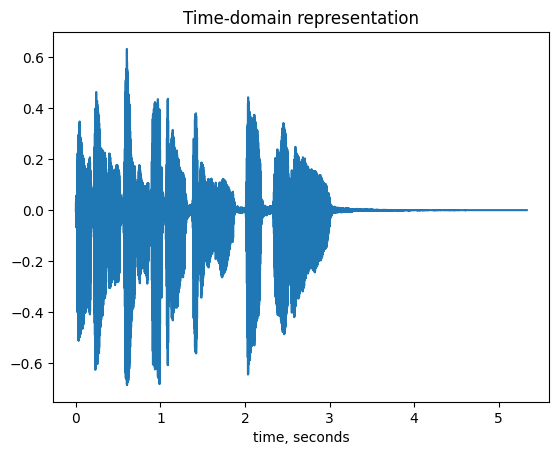

In [6]:
# Initial visualization
time = np.array(range(trumpet_sample.shape[0])) / trumpet_sampling_rate
plt.plot(time, trumpet_sample)
plt.title('Time-domain representation')
plt.xlabel('time, seconds')
plt.show()

This visualization is called the time-domain representation of a given signal. This shows us the loudness (amplitude) of sound wave changing with time. Here amplitude = 0 represents silence. These amplitudes are not very informative as they only represent the loudness of audio recording. To better understand the audio signal, it is necessary to transform it into the frequency domain. The frequency-domain representation of a signal tells us which frequencies are present in the signal.

Decompose the trumpet samples using fft and plot the results. Observe that the frequency pattern corresponds to the pitch changes.

In [7]:
# FFT for trumpet

## Analyzing a song

In the next task, you need to use the recording of a famous Ukrainian song (piano_melody.mp3) attached on cms. Your creativity is not limited here so any better ways to compelling visuals, more advanced algorithms on top of FFT or spectrogram, and explanations will be rewarded.     


1.   Load the recording, replay it, and plot in the time domain. To get a better view of how the notes change throughout a shorter time, choose a sample of the audio up to 5 seconds and plot it in the time domain. From here on out you will be working with this smaller 5-second sample.


In [8]:
# Loading sound
path = "piano_melody.mp3" # your path
samples, sampling_rate = librosa.load(path)
Audio(path)
#Creating a 5-second sample of the audio
samples = samples[sampling_rate*21:sampling_rate*26]
Audio(data=samples, rate=sampling_rate)


2.   Build a spectrogram of the sample. Explain what domain the spectrogram represents us and how can it be useful.


Text(0.5, 1.0, 'spectogram of piano melody 21 second and 26 second')

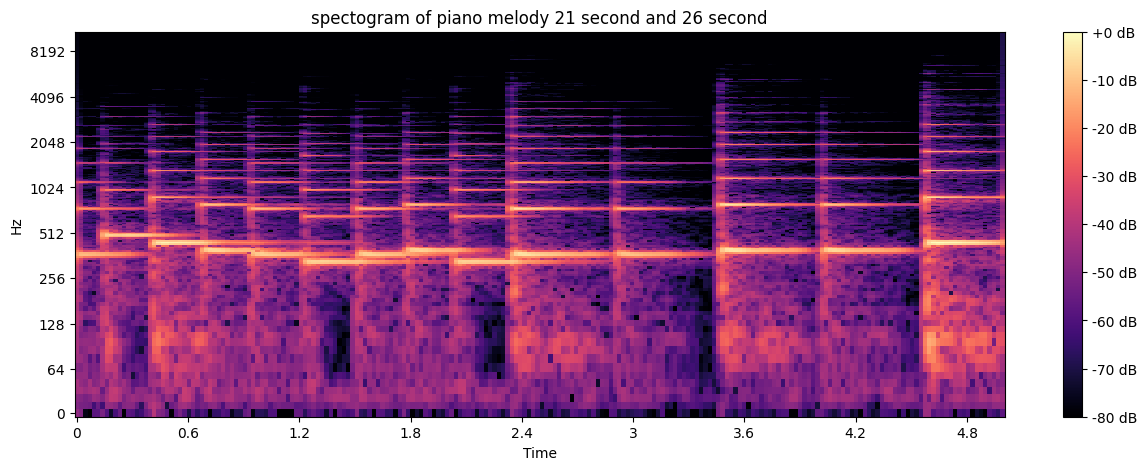

In [9]:
# Your code here
plt.figure(figsize = (15, 5))
spec =  np.abs(librosa.stft(samples, hop_length=512))
spec= librosa.amplitude_to_db(spec, ref=np.max)

librosa.display.specshow(spec, sr = sampling_rate, x_axis="time", y_axis="log")
plt.colorbar(format='%+2.0f dB')
plt.title("spectogram of piano melody 21 second and 26 second")

---
Let's begin with definition: 
 Spectrogram is a way to visually represent a signal’s loudness, or amplitude, as it varies over time at different frequencies (definition cited from: https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53). Compared to amplitude vs time plot, which only shows how amplitude evolves over time (let's take a look at it) 

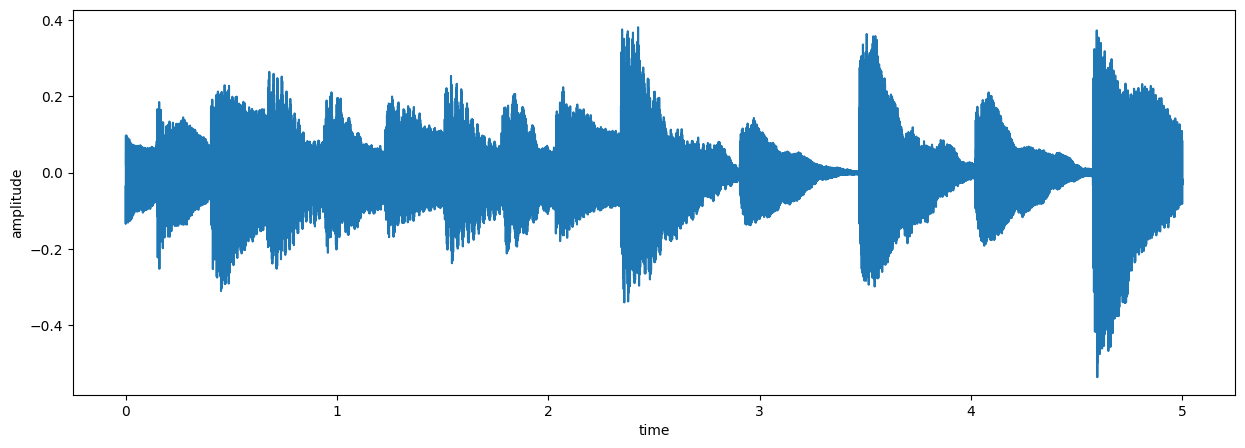

In [10]:
time = np.linspace(0, 5, len(samples))
plt.figure(figsize = (15, 5))
plt.plot(time, samples)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.show()

or a single FFT, which collapses everything into one frequency snapshot. 


Text(0, 0.5, 'magnitude')

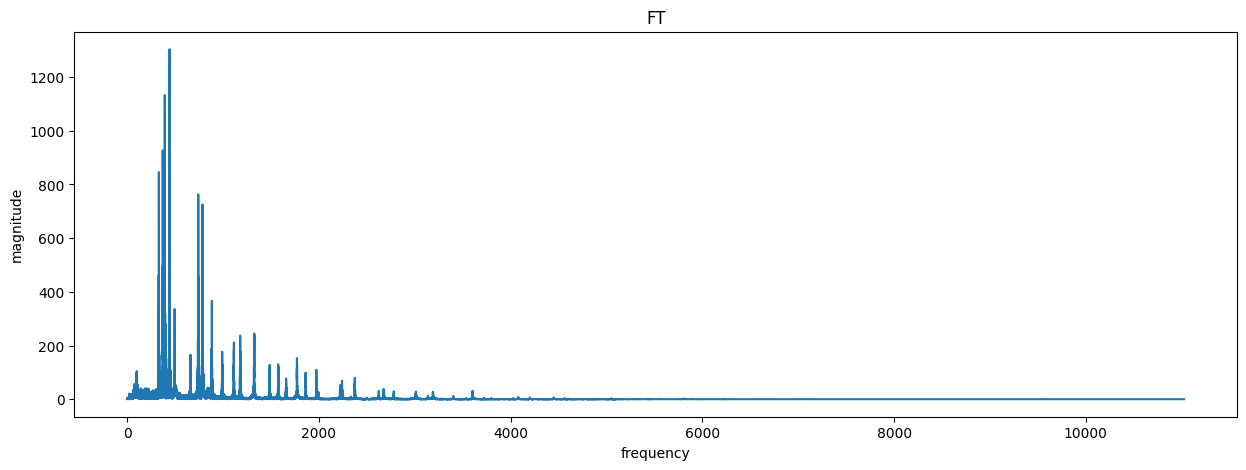

In [11]:
plt.figure(figsize  = (15, 5))
plt.plot(np.fft.fftfreq(len(samples), 1/sampling_rate)[:len(np.fft.fftfreq(len(samples), 1/sampling_rate))//2], np.abs(np.fft.fft(samples))[:len(np.abs(np.fft.fft(samples)))//2])

plt.title("FT")
plt.xlabel("frequency")
plt.ylabel("magnitude")

The three axes of the spectrogram represent: time (horizontal), frequency (vertical converted to a log-scale), and amplitude in decibels (colors, brighter colors indicate stronger presence, like a log-scale of amplitude).

Spectrogram is made with the short time FT. The signal is divided into short but overlapping time frames, and discrete FT is applied independently to each frame. Because each window is localized in time, its DFT captures the frequency content at that specific moment rather than across all signal (FT). This gives a frequency estimate at every point in time.
The window length controls the trade-off between time resolution and frequency resolution: a shorter window captures rapid temporal changes but blurs frequency detail, while a longer window gives sharper frequency resolution at the cost of  precision.

Spectrogram is useful in music analysis. Each note played on the piano produces a frequency and a series of harmonics (integer multiples of the fundamental $2f_0, 3f_0, 4f_0\ldots $ arising from the physical vibration of the piano, which vibrates not only along its full length but simultaneously)
 These appear as parallel horizontal stripes in the spectrogram. When there is a new note, a new set of horizontal stripes appears. This makes it possible to visually trace the melody.
 
 Why log y-axis and colours? Equal musical intervals such correspond to equal ratios of frequency, not equal absolute differences the jump from 220 Hz to 440 Hz sounds identical in size to the jump from 440 Hz to 880 Hz. A log scale spaces these evenly, making the melodic structure visually consistent across the entire pitch range. Humans can only perceive a small range of amplitudes, so expressing them in decibels (also a log scale) compresses the dynamic range and makes quiet details visible alongside loud ones.

3.   Transform signal to the frequency domain with FFT and study the distribution of pitches (frequencies).
Observe that the melody contains only a couple of distinct sounds, but there are a lot more spikes in the frequency domain.

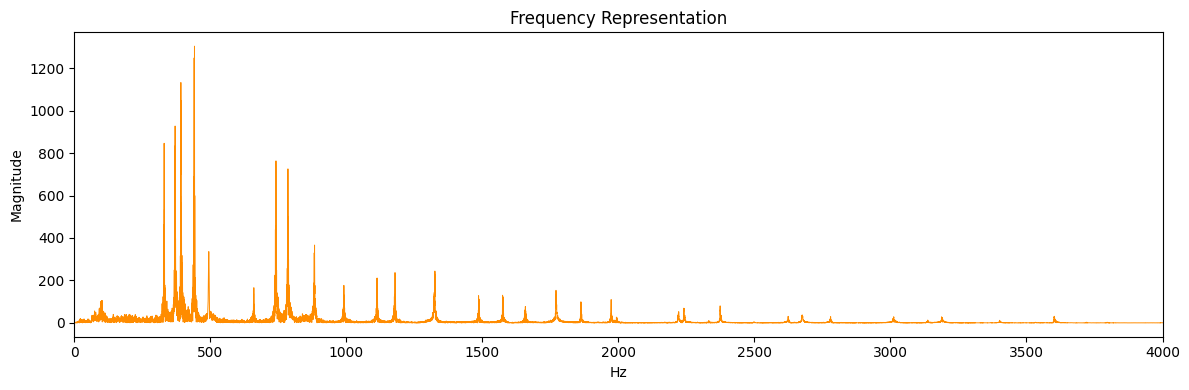

In [12]:
# Your code here
frequencies = fftfreq(len(samples), d=1/sampling_rate)
plt.figure(figsize=(12, 4))
plt.plot(frequencies[frequencies > 0], np.abs(fft(samples)[frequencies > 0]), color='darkorange', linewidth=0.7)
plt.title('Frequency Representation')
plt.xlabel('Hz')
plt.ylabel('Magnitude')
plt.xlim(0, 4000)
plt.tight_layout()
plt.show()

The Fast Fourier Transform (fft is algorithm to calculate dft) decomposes the entire 5-second sample into its constituent sinusoidal components simultaneously (Discrete Fourier Transform are faster O(nlogn) time rather than the naive O(n^2)).

Let's dive deeper into math behind dft:

how it differs from FT, Ft is 
$$ f(k) = \int_{-\infty}^{\infty} f(x) e^{-2\pi ikx} dx $$
and DFT
$$ f_k = \sum_{0}^{n-1} x_n e^{-(2\pi ikn)/N} $$
$x_n$ - element of discrete signal (column vector), $f_k$ - element of transformed discrete signal (also column vector). 

Let`s make new variable and call it $R_{kn} = e^{-(2 \pi ikn)/N}$

so we can rewrite the equation matrix mupltuplication

$$(f_0...f_{K-1})^T = \begin{pmatrix}
R_{0,0} &  \cdots & R_{0, N-1} \\
\vdots  & \vdots & \vdots \\
R_{K-1, 0} & \cdots & R_{K-1, N-1}
\end{pmatrix} (x_0...x_{K-1})^T$$
                

If we apply a simple algorithm for matrix multiplication it will take too much time. So we use the FFT algorithm here to speed up computation. FFT achieves this by exploiting the symmetry and periodicity of the complex exponentials $R_{kn}$​, factoring the matrix into sparse components and avoiding some calculations.

The result of the DFT is a complex-valued array. Taking its absolute value gives us the magnitude spectrum: how strongly each frequency contributes to the signal.
Because the piano signal is real-valued, the DFT output is conjugate-symmetric. This is why we discard it and plot only positive frequencies.
Finally, this explains why the spectrum contains far more spikes than there are notes in the melody. Each piano note does not produce a single spike it produces an entire cluster: one spike at the fundamental frequency $
f_0$​ and additional spikes at harmonics $2f_0, 3f_0, 4f_0\ldots$ simultaneously. So the spike count always exceeds the note count.

### Bonus visualizations

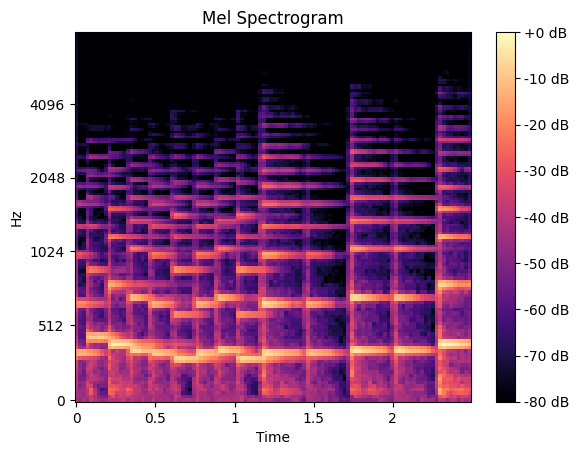

In [13]:
mel_spect = librosa.feature.melspectrogram(y=samples, sr=sampling_rate, n_fft=2048, hop_length=1024)
mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
librosa.display.specshow(mel_spect, y_axis='mel', fmax=8000, x_axis='time')
plt.title('Mel Spectrogram')
plt.colorbar(format='%+2.0f dB')

A mel spectrogram is a spectrogram where the frequencies are converted to the mel scale.

The spetrogram treats all freqs equally. The Mel squishes high frequencies together and stretches low frequencies apart, so that distances on the axis match how human  hears pitch differences.

Piano notes follow this perceptual spacing naturally the note structure looks visually even and regular.

Text(0, 0.5, 'Pitch class')

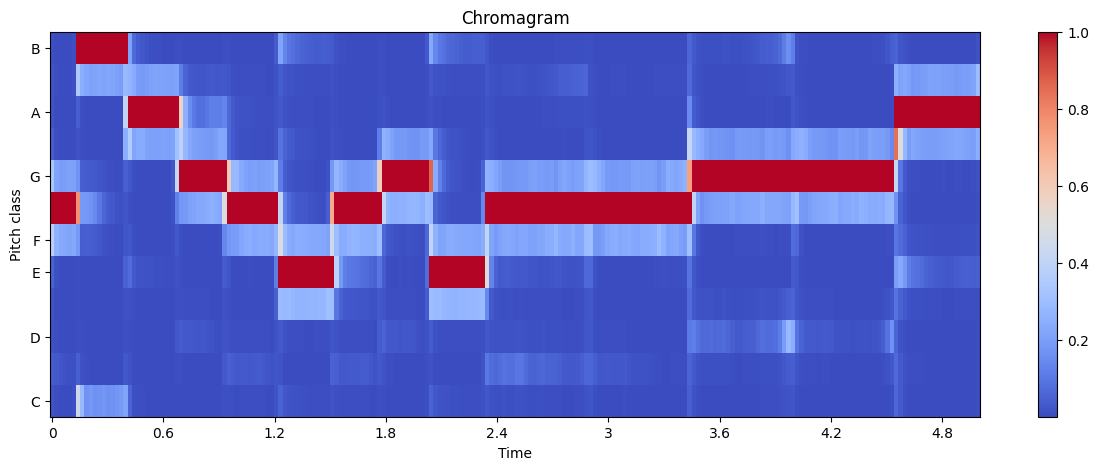

In [14]:
chroma = librosa.feature.chroma_stft(y=samples, sr=sampling_rate)

plt.figure(figsize=(15, 5))
librosa.display.specshow(chroma, sr=sampling_rate, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar()
plt.title('Chromagram')
plt.xlabel('Time')
plt.ylabel('Pitch class')

A chromagram collapses the full frequency spectrum onto the 12 pitch classes of the musical scale (C, C#, D, D#, E, F, F#, G, G#, A, A#, B). It works by summing the STFT energy of all frequencies that map to each pitch class at every time frame. Bright columns indicate a note being actively played. This is more directly useful than the raw FFT for identifying which notes are in the melody, because it groups harmonics of the same note together instead of showing them as separate spikes.

4. Apply averaging to the initial signal. Averaging is a procedure that reduces number of samples by taking mean of each n of our samples. Experiment with n and determine whichever will work best to both reduce the noise and not loose any information. You can propose other ways to efficiently denoise the signal.

In [15]:
# Your code here

---
>**Your explanations here**

---

5. Match fundamental pitches you discovered to the standard note frequencies and display them in a table like the one outlined below.

|Detected frequency(Hz) | Assigned frequency(Hz) | Output note|   
|:---------------------:|:----------------------:|:----------:|
|393.2 |391.9| G4  

In [16]:
# Your code here

In the last task you will use the recording of Lynyrd Skynyrd - Free Bird.

6.    Experiment with filtering of free_bird.mp3 using Butterworth filter (or other ways which you prefer), so that only bass could be heard. (Hint: you can use [scipy.signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)). Replay original and filtered audios. Plot their time and frequency domains.

In [17]:
free_bird_path = # your path
free_bird_samples, free_bird_sampling_rate = librosa.load(free_bird_path)
# Your code here

SyntaxError: invalid syntax (730183931.py, line 1)

---
>**Your explanations here**

---

## Summary

1. What is Fourier transform? How can it be used in signal processing?


---

The **Fourier Transform** is a mathematical operation that decomposes a signal (a function of time or space) into its constituent sinusoidal components, each characterized by a specific frequency, amplitude, and phase. For a continuous signal f(t), the Fourier Transform is defined as:

$$\hat{f}(\xi) = \int_{-\infty}^{\infty} f(t)\, e^{-2\pi i \xi t}\, dt$$

For discrete, finite signals (as in digital audio), the Discrete Fourier Transform (DFT) is used, computed efficiently via the Fast Fourier Transform (FFT) algorithm in O(N log N) time.

In **signal processing**, the Fourier Transform is indispensable:

- **Spectral analysis:** It reveals which frequencies are present in a signal and with what intensity — for example, identifying the pitch of a musical note from a recorded waveform.
- **Filtering:** By transforming to the frequency domain, applying a mask (e.g., zeroing out high frequencies for a low-pass filter), and transforming back, we can remove noise or isolate specific frequency bands (as in the Butterworth filter exercise).
- **Compression:** Formats like MP3 and JPEG exploit the fact that most energy concentrates in a few frequencies, discarding inaudible/invisible components.
- **Feature extraction:** Spectrograms and chromagrams, both derived from the Fourier Transform, are standard features for music information retrieval, speech recognition, and audio classification.

---

2. What are time and frequency domains and how can they be useful?

---

The **time domain** represents a signal as amplitude versus time — it shows *when* events happen and how loud they are, but gives no direct information about which frequencies are present.

The **frequency domain** represents the same signal as magnitude versus frequency — it shows *which* frequencies are present and their relative strengths, but collapses all temporal information.

These two representations are complementary and connected by the Fourier Transform (time → frequency) and its inverse (frequency → time). Each is useful for different purposes:

- The time domain is natural for observing the overall shape of a waveform, locating note onsets, measuring duration, and detecting silence or transients.
- The frequency domain is essential for identifying pitches (fundamental frequencies), understanding the timbral content of a sound (harmonics/overtones), filtering unwanted frequency bands (e.g., isolating bass with a low-pass filter), and detecting which notes are being played in a musical signal.

In practice, hybrid representations like the spectrogram (Short-Time Fourier Transform) combine both by showing frequency content as it evolves over time, giving the best of both worlds.

---

3. What is averaging and what is its purpose?

---

**Averaging** (also called downsampling by local mean) is a noise-reduction technique in which consecutive groups of *n* samples are replaced by their arithmetic mean, producing a shorter, smoother signal.

Its purpose is twofold:

1. **Noise reduction.** Random noise tends to cancel when averaged, because positive and negative deviations offset each other. After averaging over *n* samples, the noise standard deviation drops by a factor of roughly √n, improving the signal-to-noise ratio.

2. **Data reduction.** The resulting signal has N/n samples instead of N, making subsequent processing (such as FFT or peak detection) faster and less cluttered.

However, the trade-off is a loss of high-frequency information: averaging acts as a low-pass filter, attenuating frequencies above approximately f_s/(2n), where f_s is the original sampling rate. Choosing *n* too large can therefore blur or remove genuine frequency components of interest (such as harmonics of a musical note). The goal is to pick the smallest *n* that sufficiently suppresses noise while preserving all musically relevant frequencies.

---

3.   Transform signal to the frequency domain with FFT and study the distribution of pitches (frequencies).
Observe that the melody contains only a couple of distinct sounds, but there are a lot more spikes in the frequency domain.

In [ ]:
# Your code here

4. Apply averaging to the initial signal. Averaging is a procedure that reduces number of samples by taking mean of each n of our samples. Experiment with n and determine whichever will work best to both reduce the noise and not loose any information. You can propose other ways to efficiently denoise the signal.

In [ ]:
# Your code here

---
>**Your explanations here**

---

5. Match fundamental pitches you discovered to the standard note frequencies and display them in a table like the one outlined below.

|Detected frequency(Hz) | Assigned frequency(Hz) | Output note|   
|:---------------------:|:----------------------:|:----------:|
|393.2 |391.9| G4  

In [ ]:
# Your code here

In the last task you will use the recording of Lynyrd Skynyrd - Free Bird.

6.    Experiment with filtering of free_bird.mp3 using Butterworth filter (or other ways which you prefer), so that only bass could be heard. (Hint: you can use [scipy.signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)). Replay original and filtered audios. Plot their time and frequency domains.

In [ ]:
free_bird_path = # your path
free_bird_samples, free_bird_sampling_rate = librosa.load(free_bird_path)
# Your code here

---
>**Your explanations here**

---

## Summary

1. What is Fourier transform? How can it be used in signal processing?


---

The **Fourier Transform** is a mathematical operation that decomposes a signal (a function of time or space) into its constituent sinusoidal components, each characterized by a specific frequency, amplitude, and phase. For a continuous signal f(t), the Fourier Transform is defined as:

$$\hat{f}(\xi) = \int_{-\infty}^{\infty} f(t)\, e^{-2\pi i \xi t}\, dt$$

For discrete, finite signals (as in digital audio), the Discrete Fourier Transform (DFT) is used, computed efficiently via the Fast Fourier Transform (FFT) algorithm in O(N log N) time.

In **signal processing**, the Fourier Transform is indispensable:

- **Spectral analysis:** It reveals which frequencies are present in a signal and with what intensity — for example, identifying the pitch of a musical note from a recorded waveform.
- **Filtering:** By transforming to the frequency domain, applying a mask (e.g., zeroing out high frequencies for a low-pass filter), and transforming back, we can remove noise or isolate specific frequency bands (as in the Butterworth filter exercise).
- **Compression:** Formats like MP3 and JPEG exploit the fact that most energy concentrates in a few frequencies, discarding inaudible/invisible components.
- **Feature extraction:** Spectrograms and chromagrams, both derived from the Fourier Transform, are standard features for music information retrieval, speech recognition, and audio classification.

---

2. What are time and frequency domains and how can they be useful?

---

The **time domain** represents a signal as amplitude versus time — it shows *when* events happen and how loud they are, but gives no direct information about which frequencies are present.

The **frequency domain** represents the same signal as magnitude versus frequency — it shows *which* frequencies are present and their relative strengths, but collapses all temporal information.

These two representations are complementary and connected by the Fourier Transform (time → frequency) and its inverse (frequency → time). Each is useful for different purposes:

- The time domain is natural for observing the overall shape of a waveform, locating note onsets, measuring duration, and detecting silence or transients.
- The frequency domain is essential for identifying pitches (fundamental frequencies), understanding the timbral content of a sound (harmonics/overtones), filtering unwanted frequency bands (e.g., isolating bass with a low-pass filter), and detecting which notes are being played in a musical signal.

In practice, hybrid representations like the spectrogram (Short-Time Fourier Transform) combine both by showing frequency content as it evolves over time, giving the best of both worlds.

---

3. What is averaging and what is its purpose?

---

**Averaging** (also called downsampling by local mean) is a noise-reduction technique in which consecutive groups of *n* samples are replaced by their arithmetic mean, producing a shorter, smoother signal.

Its purpose is twofold:

1. **Noise reduction.** Random noise tends to cancel when averaged, because positive and negative deviations offset each other. After averaging over *n* samples, the noise standard deviation drops by a factor of roughly √n, improving the signal-to-noise ratio.

2. **Data reduction.** The resulting signal has N/n samples instead of N, making subsequent processing (such as FFT or peak detection) faster and less cluttered.

However, the trade-off is a loss of high-frequency information: averaging acts as a low-pass filter, attenuating frequencies above approximately f_s/(2n), where f_s is the original sampling rate. Choosing *n* too large can therefore blur or remove genuine frequency components of interest (such as harmonics of a musical note). The goal is to pick the smallest *n* that sufficiently suppresses noise while preserving all musically relevant frequencies.

---